<a href="https://colab.research.google.com/github/IsaacFigNewton/Small-Projects/blob/main/DAG_to_Multiplexed_Hypergraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and Config

In [123]:
import networkx as nx
from typing import Iterable, List, Set, FrozenSet, Dict

# Helpers

In [124]:
def get_descendant_sets(G: nx.DiGraph) -> Dict[FrozenSet[str], str]:
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("Input graph must be a DAG.")
    hyperverts = {v: set(nx.descendants(G, v)).union({v}) for v in G.nodes()}
    return {frozenset(s): v for v, s in hyperverts.items()}

In [125]:
def group_sets_by_size(sets: List[FrozenSet[str]]) -> List[List[FrozenSet[str]]]:
    # group descendant sets by size
    max_size = max({len(s) for s in sets})
    sets_by_size = [[]]*max_size
    for s in sets:
        sets_by_size[len(s)-1].append(s)
    return sets_by_size[-1:]

In [126]:
def get_maximal_disjoint_set_pair(sets_by_size: List[List[FrozenSet[str]]]):
    # Try pairs in order: outer loop over larger sets first
    for descendant_sets_a in sets_by_size:
        for A in descendant_sets_a:
          for descendant_sets_b in sets_by_size:
              for B in descendant_sets_b:
                  # if maximal disjoint pair found
                  if A.isdisjoint(B):
                      return A, B

    raise("No maximal disjoint pair found.")

In [127]:
def get_maximal_disjoint_subsets(
      descendant_sets: List[FrozenSet],
    ) -> List[FrozenSet]:
    if len(descendant_sets) == 1:
      return [descendant_sets[0]]

    # get disjoint pairs until not possible
    H = []
    checked_verts = set()
    verts_to_check = set()
    for s in descendant_sets:
        verts_to_check = verts_to_check.union(s)

    while len(checked_verts) < len(verts_to_check):
        disjoint_descendant_sets = [C for C in descendant_sets if C.isdisjoint(checked_verts)]
        # if there are no more disjoint sets to check
        if len(disjoint_descendant_sets) == 0:
          break

        sets_by_size = group_sets_by_size(disjoint_descendant_sets)
        # default case, where every node is a descendant of a root node
        if len(sets_by_size[0]) > 0 and sets_by_size[0][0] == verts_to_check:
          # add the root to the graph and return
          H.append(sets_by_size[0][0])
          return H

        # otherwise we have > 1 root node
        else:
          A, B = get_maximal_disjoint_set_pair(sets_by_size)
          # Build node as union of the two disjoint sets
          H.append(A)
          H.append(B)
          # update the set that can't be overlapped
          checked_verts = checked_verts.union(A).union(B)

    return H

In [221]:
def build_multiplexed_hypergraph(descendant_sets: List[FrozenSet], depth: int=-1) -> nx.DiGraph:
    """
    Build a multiplexed hypergraph (as a networkx.DiGraph) from a list/iterable of descendant sets.

    Parameters
    ----------
    descendant_sets : Iterable[Set]
        An iterable of sets, where each set is a set of original-graph vertex identifiers.

    Returns
    -------
    H : networkx.DiGraph
        A directed graph whose nodes are frozensets representing disjoint subset nodes.
        Edges go from a larger disjoint node to roots of recursively-built subgraphs.
    """
    if len(descendant_sets) == 0:
        raise ValueError("Input descendant_sets must not be empty.")

    # add nodes based on maximal disjoint subsets of nodes' descendants
    H = nx.DiGraph()
    max_disjoint_subsets = get_maximal_disjoint_subsets(descendant_sets)
    H.add_nodes_from([(n, {"layer": depth}) for n in max_disjoint_subsets])

    for h in list(H.nodes()):
        # Find descendant sets that intersect h (nonempty intersection)\
        #   that are not h
        subgraph_descendant_sets = [
            s
            for s in descendant_sets
            if not s.isdisjoint(h) and s != h
        ]

        # if it's a non-atomic hypervert
        if len(subgraph_descendant_sets) != 0 and depth != 0:
          sub_H = build_multiplexed_hypergraph(
              subgraph_descendant_sets,
              depth-1
          )

          # Merge nodes and edges from sub_H into H
          for node in sub_H.nodes(data=True):
              H.add_node(node[0])
              H.nodes[node[0]].update(node[1])
          for u, v in sub_H.edges():
              H.add_edge(u, v)

          # Identify roots in sub_H: nodes with in-degree 0 in sub_H
          roots = [n for n, deg in sub_H.in_degree() if deg == 0]
          # Add edges from h to each root
          for root in roots:
              H.add_edge(h, root)

    return H

# Test

In [222]:
sample_dag = nx.DiGraph()
sample_dag.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 8),
    (3, 6),
    (6, 7),
    (5, 8)
])

In [223]:
test_descendants_dict = get_descendant_sets(sample_dag)
test_descendants = list(test_descendants_dict.keys())
test_descendants

[frozenset({1, 2, 3, 4, 5, 6, 7, 8}),
 frozenset({2, 4, 5, 8}),
 frozenset({3, 4, 5, 6, 7, 8}),
 frozenset({4, 5, 8}),
 frozenset({5, 8}),
 frozenset({8}),
 frozenset({6, 7}),
 frozenset({7})]

In [224]:
get_maximal_disjoint_subsets(test_descendants)

[frozenset({1, 2, 3, 4, 5, 6, 7, 8})]

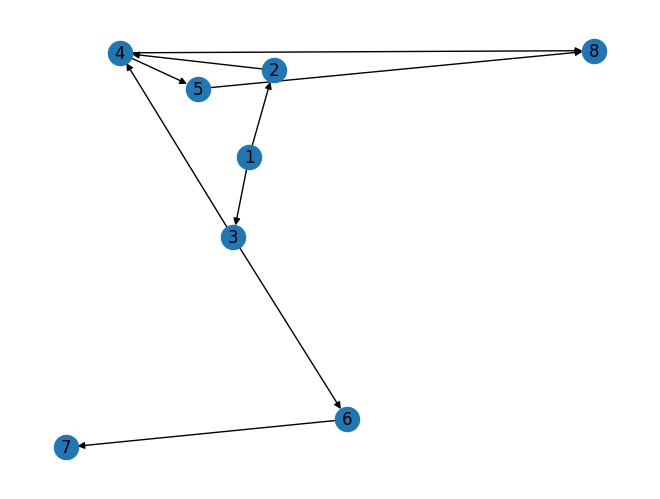

In [225]:
nx.draw(sample_dag, with_labels=True)

Nodes (as frozensets):
(frozenset({1, 2, 3, 4, 5, 6, 7, 8}), {'layer': 3})
(frozenset({8, 2, 4, 5}), {'layer': 2})
(frozenset({6, 7}), {'layer': 2})
(frozenset({3, 4, 5, 6, 7, 8}), {'layer': 1})
(frozenset({8, 4, 5}), {'layer': 0})
(frozenset({7}), {'layer': 0})

Edges:
frozenset({1, 2, 3, 4, 5, 6, 7, 8}) -> frozenset({8, 2, 4, 5})
frozenset({1, 2, 3, 4, 5, 6, 7, 8}) -> frozenset({6, 7})
frozenset({8, 2, 4, 5}) -> frozenset({3, 4, 5, 6, 7, 8})
frozenset({6, 7}) -> frozenset({3, 4, 5, 6, 7, 8})
frozenset({3, 4, 5, 6, 7, 8}) -> frozenset({8, 4, 5})
frozenset({3, 4, 5, 6, 7, 8}) -> frozenset({7})


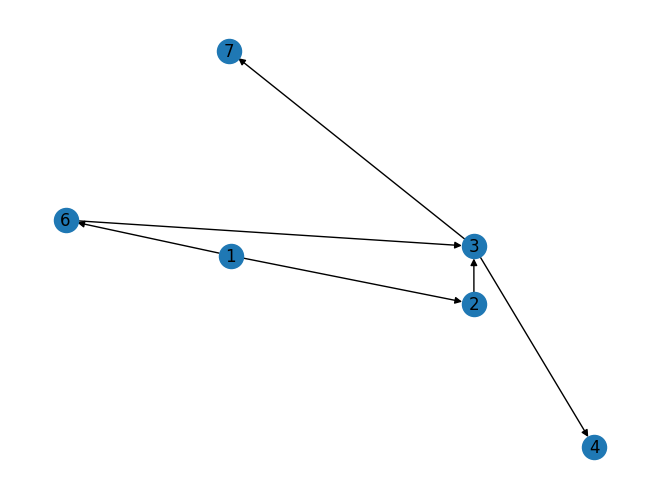

In [231]:
H = build_multiplexed_hypergraph(test_descendants, 3)

print("Nodes (as frozensets):")
for n in H.nodes(data=True):
    print(n)
print("\nEdges:")
for u, v in H.edges():
    print(u, "->", v)

H_relabelled = nx.relabel_nodes(H, test_descendants_dict)
nx.draw(H_relabelled, with_labels=True)